In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from vit_scratch import ViT, load_cifar10, train_vit, IMG_SIZE, PATCH_SIZE

tf.random.set_seed(0)
np.random.seed(0)


In [2]:
(x_train, y_train), (x_test, y_test) = load_cifar10()
model = ViT()
history = train_vit(model, x_train, y_train, x_test, y_test, epochs=20, batch_size=128)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step - accuracy: 0.3511 - loss: 1.7583 - val_accuracy: 0.4438 - val_loss: 1.5247
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 757s 2s/step - accuracy: 0.4760 - loss: 1.4438 - val_accuracy: 0.4977 - val_loss: 1.3933
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.5255 - loss: 1.3082 - val_accuracy: 0.5314 - val_loss: 1.2938
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 289s 739ms/step - accuracy: 0.5581 - loss: 1.2181 - val_accuracy: 0.5522 - val_loss: 1.2508
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 311s 712ms/step - accuracy: 0.5836 - loss: 1.1575 - val_accuracy: 0.5418 - val_loss: 1.2759
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 279s 713ms/step - accuracy: 0.6070 - loss: 1.0968 - val_accuracy: 0.5551 - val_loss: 1.2431
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 286s 731ms/step - accuracy: 0.6206 - loss: 1.0519 - val_accuracy: 0.5681 - val_loss: 1.2168
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 285s 729ms/step - accuracy: 0.6373 - loss: 1.

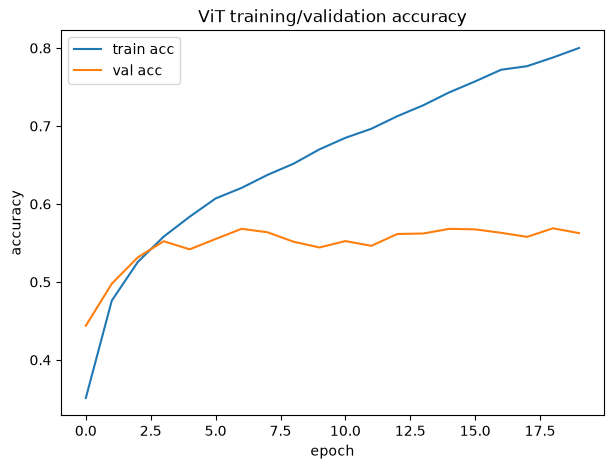

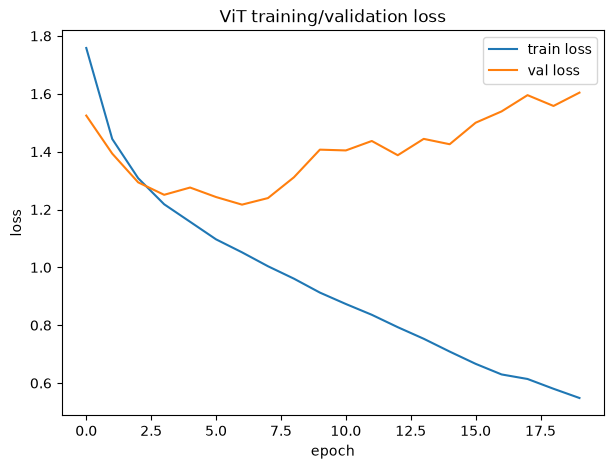

In [3]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.title("ViT training/validation accuracy")
plt.legend(); plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("ViT training/validation loss")
plt.legend(); plt.show()


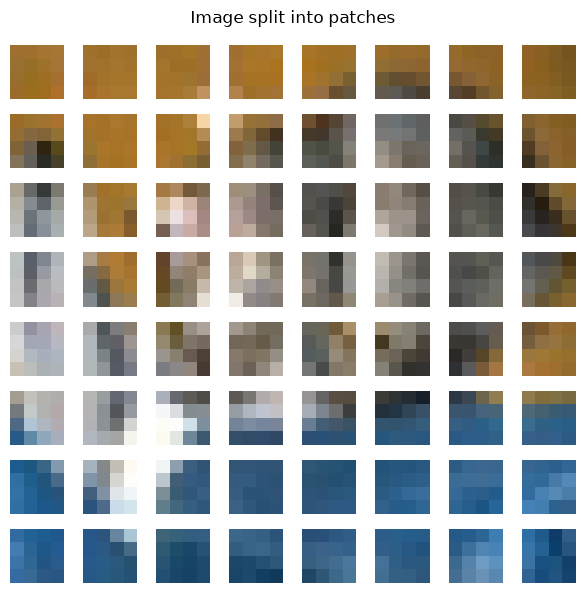

In [4]:
def show_patches(image, patch_size=PATCH_SIZE):
    n = IMG_SIZE // patch_size
    fig, axes = plt.subplots(n, n, figsize=(6, 6))
    img = (image + 1) / 2
    for i in range(n):
        for j in range(n):
            patch = img[i * patch_size:(i + 1) * patch_size, j * patch_size:(j + 1) * patch_size]
            axes[i, j].imshow(patch)
            axes[i, j].axis("off")
    plt.suptitle("Image split into patches")
    plt.tight_layout()
    plt.show()

show_patches(x_test[0])


In [5]:
sample_idx = np.random.choice(len(x_test), 6, replace=False)
sample_images = x_test[sample_idx]
_ = model(sample_images)
attn_maps = model.get_attention_maps()
last_layer_attn = attn_maps[-1]  # (B, heads, tokens, tokens)

cls_attn = tf.reduce_mean(last_layer_attn[:, :, 0, 1:], axis=1)  # avg over heads, cls->patches
grid_size = IMG_SIZE // PATCH_SIZE
cls_attn = tf.reshape(cls_attn, (-1, grid_size, grid_size))


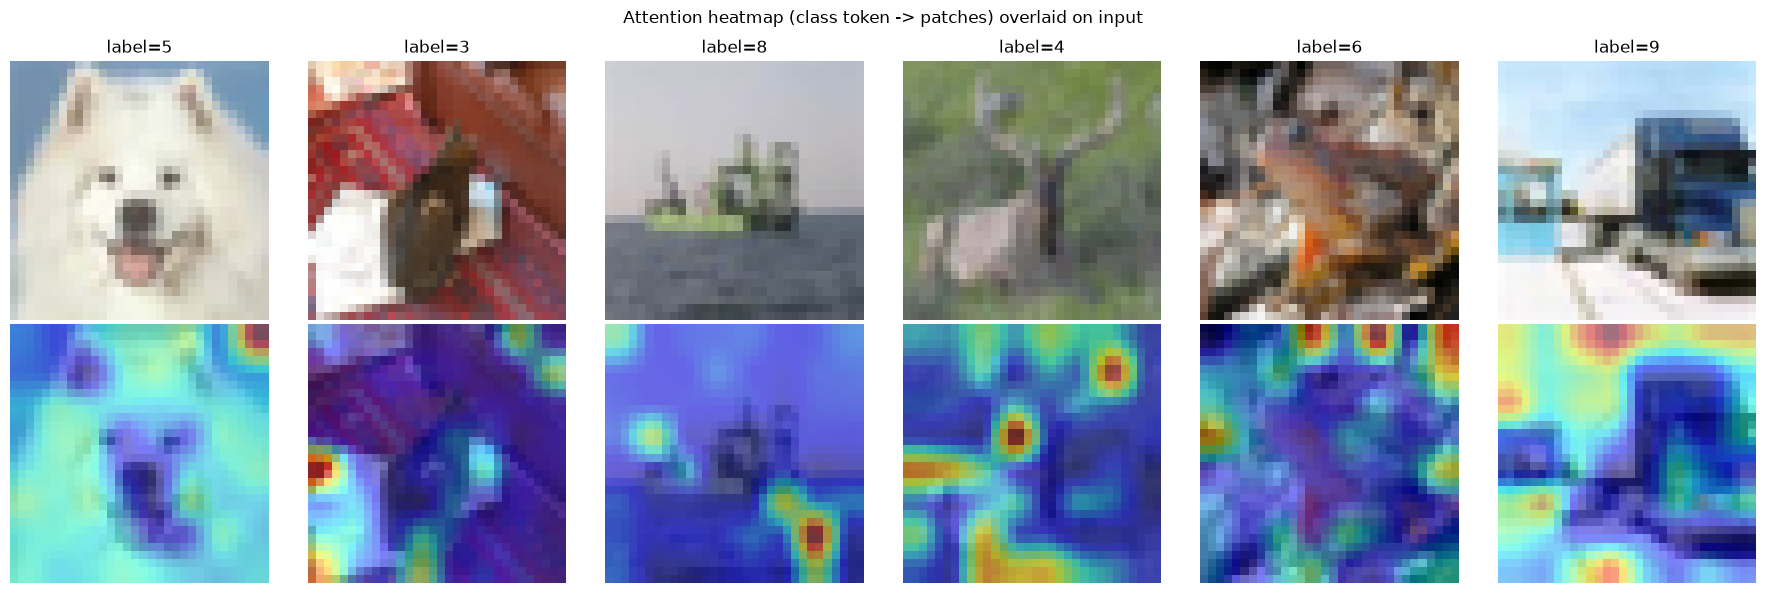

In [6]:
fig, axes = plt.subplots(2, len(sample_idx), figsize=(3 * len(sample_idx), 6))
for i in range(len(sample_idx)):
    img = (sample_images[i] + 1) / 2
    heat = cls_attn[i].numpy()
    heat_resized = tf.image.resize(heat[..., None], (IMG_SIZE, IMG_SIZE)).numpy().squeeze(-1)

    axes[0, i].imshow(img)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"label={int(y_test[sample_idx[i]])}")

    axes[1, i].imshow(img)
    axes[1, i].imshow(heat_resized, cmap="jet", alpha=0.5)
    axes[1, i].axis("off")
plt.suptitle("Attention heatmap (class token -> patches) overlaid on input")
plt.tight_layout()
plt.show()
